# Seguimiento mediante diferencia de imágenes

Este notebook muestra la implementación básica del método de diferencia de imágenes.

El método compara fotogramas consecutivos para detectar regiones de la imagen que cambian con el tiempo. En este proyecto, esta idea se aplica a una secuencia completa de vídeo para estimar la posición de la región móvil principal mediante su centroide.

Este notebook se utiliza como una demostración inicial del método. Los experimentos completos con todos los escenarios sintéticos y reales se ejecutan desde los scripts de la carpeta `src/`.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_dir = current_dir.parent
else:
    project_dir = current_dir

video_path = project_dir / "data" / "synthetic_videos" / "synthetic_clean_1.mp4"

output_video_path = project_dir / "outputs" / "processed_videos" / "synthetic" / "frame_difference_synthetic_clean_1_demo.mp4"
output_plot_path = project_dir / "outputs" / "plots" / "synthetic" / "trajectory_synthetic_clean_1_demo.png"
output_csv_path = project_dir / "outputs" / "plots" / "synthetic" / "trajectory_synthetic_clean_1_demo.csv"

output_video_path.parent.mkdir(parents=True, exist_ok=True)
output_plot_path.parent.mkdir(parents=True, exist_ok=True)

print("Directorio del proyecto:", project_dir)
print("Ruta del vídeo:", video_path)
print("Existe el vídeo:", video_path.exists())

Directorio del proyecto: c:\Users\34689\Desktop\Glole\U\masterus\percep
Ruta del vídeo: c:\Users\34689\Desktop\Glole\U\masterus\percep\data\synthetic_videos\synthetic_clean_1.mp4
Existe el vídeo: True


FPS: 30.0
Número de fotogramas: 180
Resolución: 640 x 360


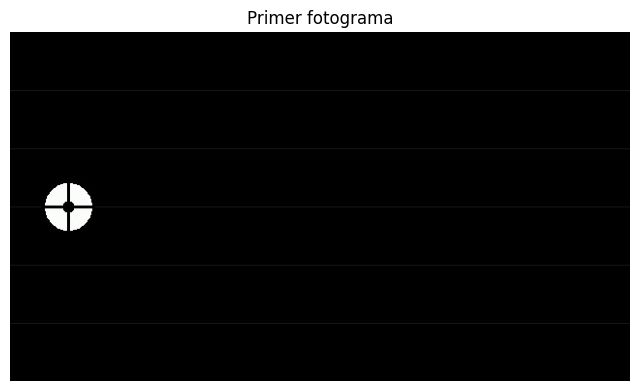

In [14]:
cap = cv2.VideoCapture(str(video_path))

if not cap.isOpened():
    raise RuntimeError("No se pudo abrir el vídeo")

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("FPS:", fps)
print("Número de fotogramas:", frame_count)
print("Resolución:", width, "x", height)

ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("No se pudo leer el primer fotograma")

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 5))
plt.imshow(frame_rgb)
plt.axis("off")
plt.title("Primer fotograma")
plt.show()

In [15]:
def track_motion_with_frame_difference(
    input_video_path: Path,
    output_video_path: Path,
    threshold_value: int = 25,
    min_area: int = 300,
    kernel_size: int = 5,
):
    """
    Realiza el seguimiento de la región móvil principal mediante diferencia de imágenes.

    El método compara fotogramas consecutivos en escala de grises, obtiene una máscara
    de movimiento, extrae contornos y calcula el centroide de la región móvil principal.
    """

    cap = cv2.VideoCapture(str(input_video_path))

    if not cap.isOpened():
        raise RuntimeError("No se pudo abrir el vídeo de entrada")

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_video_path), fourcc, fps, (width, height))

    ret, previous_frame = cap.read()

    if not ret:
        raise RuntimeError("No se pudo leer el primer fotograma")

    previous_gray = cv2.cvtColor(previous_frame, cv2.COLOR_BGR2GRAY)
    previous_gray = cv2.GaussianBlur(previous_gray, (5, 5), 0)

    kernel = np.ones((kernel_size, kernel_size), np.uint8)

    trajectory = []
    frame_index = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, (5, 5), 0)

        frame_difference = cv2.absdiff(previous_gray, gray)

        _, motion_mask = cv2.threshold(
            frame_difference,
            threshold_value,
            255,
            cv2.THRESH_BINARY
        )

        motion_mask = cv2.morphologyEx(motion_mask, cv2.MORPH_OPEN, kernel)
        motion_mask = cv2.dilate(motion_mask, kernel, iterations=2)

        contours, _ = cv2.findContours(
            motion_mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        detected = False
        cx, cy = None, None

        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(largest_contour)

            if area > min_area:
                x, y, w, h = cv2.boundingRect(largest_contour)

                cx = x + w // 2
                cy = y + h // 2

                trajectory.append({
                    "frame": frame_index,
                    "x": cx,
                    "y": cy,
                    "area": area
                })

                detected = True

                cv2.rectangle(
                    frame,
                    (x, y),
                    (x + w, y + h),
                    (0, 255, 0),
                    2
                )

                cv2.circle(
                    frame,
                    (cx, cy),
                    5,
                    (0, 0, 255),
                    -1
                )

        status_text = "detectado" if detected else "no detectado"

        cv2.putText(
            frame,
            f"Fotograma: {frame_index} | Movimiento: {status_text}",
            (20, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2
        )

        if detected:
            cv2.putText(
                frame,
                f"Centroide: ({cx}, {cy})",
                (20, 60),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 255, 255),
                2
            )

        writer.write(frame)

        previous_gray = gray.copy()
        frame_index += 1

    cap.release()
    writer.release()

    trajectory_df = pd.DataFrame(trajectory)

    return trajectory_df

In [16]:
trajectory_df = track_motion_with_frame_difference(
    input_video_path=video_path,
    output_video_path=output_video_path,
    threshold_value=25,
    min_area=300,
    kernel_size=5
)

print("Vídeo procesado guardado en:", output_video_path)
print("Número de puntos detectados:", len(trajectory_df))

trajectory_df.head()

Vídeo procesado guardado en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\processed_videos\synthetic\frame_difference_synthetic_clean_1_demo.mp4
Número de puntos detectados: 176


,frame,x,y,area
0,0,61,185,3294.0
1,1,64,193,3277.0
2,2,67,202,3403.0
3,3,70,210,3250.0
4,4,73,218,3264.0


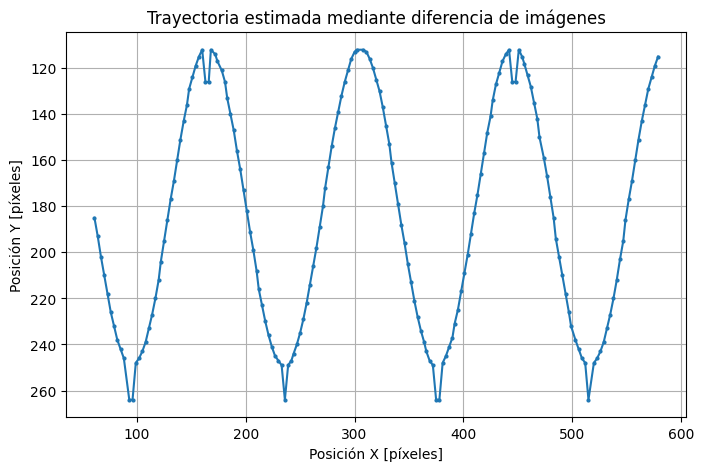

Trayectoria guardada en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\trajectory_synthetic_clean_1_demo.csv
Gráfica guardada en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\trajectory_synthetic_clean_1_demo.png


In [17]:
trajectory_df.to_csv(output_csv_path, index=False)

plt.figure(figsize=(8, 5))
plt.plot(trajectory_df["x"], trajectory_df["y"], marker="o", markersize=2)
plt.gca().invert_yaxis()
plt.xlabel("Posición X [píxeles]")
plt.ylabel("Posición Y [píxeles]")
plt.title("Trayectoria estimada mediante diferencia de imágenes")
plt.grid(True)
plt.savefig(output_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Trayectoria guardada en:", output_csv_path)
print("Gráfica guardada en:", output_plot_path)

## Resultado

El método de diferencia de imágenes permite detectar la región móvil en el vídeo sintético y estimar una trayectoria aproximada a partir del centroide.

Sin embargo, este método no identifica el objeto de forma semántica. Solo detecta regiones que cambian entre fotogramas consecutivos. Por ello, puede ser sensible a cambios de iluminación, sombras, ruido u otros elementos móviles de la escena.

En los experimentos completos del proyecto, este método se comparará con Lucas-Kanade en distintos escenarios sintéticos y reales.